# 6장 : 신경망을 활용한 데이터 적합

 + 선형 모델과 비교한 비선형 활성 함수의 차이
 + 파이토치의 nn 모듈 다루기
 + 신경망을 활용한 선형 적합 문제 풀기

6장에서는 모델 아키텍처를 완전한 인공 신경망으로 바꿔서, 온도 변환 문제를 풀어 본다.

지금까지 다룬 기본 작업들을, 앞으로 프로젝트를 수행할 때마다 매일같이 사용할 파이토치의 기능으로 구현해본다.

## 6.1 인공 뉴런

딥러닝의 핵심인 신경망은 복잡한 함수를 단순한 함수들의 합성으로 표현할 수 있는 수학적 엔티티다.

인공 신경망과 사람의 신경망은 복잡한 함수에 근사하기 위해 어느 정도 유사한 수학적 접근을 보이며 이 전략은 매우 효과적으로 동작한다.

  - $\textbf{활성함수}^{\text{activation function}}$ : $o = f(wx + b)$
    - $x, o$ : 입력과 출력. 일반적으로 $x$나 $o$는 단순 스칼라값 혹은 벡터이다
    - $f$ : 비선형 함수(활성함수). $tanh, \quad \text{sigmoid}, \quad \text{ReLU}$등이 있다.
    - $w, b$ : 모델의 파라미터. $w$는 가중치, $b$는 편향이라고 부른다. 일반적으로 $w$는 단일 스칼라 혹은 행렬이며, $b$는 스칼라나 벡터이다.
    - 가중치와 편향이 행렬, 벡터 형태인 경우는 여러 개의 뉴런을 나타내므로 이런 표현식은 $\textbf{계층}^{\text{layer}}$이라 부른다.

### 6.1.1 다중 계층 신경망 합성하기

다중 계층 신경망은 지금까지 다룬 함수들의 합성으로 만들어진다. (`w_0`는 행렬, `x`는 벡터)

```python
x_1 = f(w_0 * x + b_0)
x_2 = f(w_1 * x_1 + b_1)
...
y = f(w_n * x_n + b_n)
```

### 6.1.2 오차 함수

신경망은 선형 모델과 달리 비선형 활성 함수를 사용하기에, 오차를 제곱한 손실 함수가 단순한 볼록 함수 형태의 오차 곡선이 되지 못한다.

따라서 훈련과정에서 업데이트되는 파라미터 값에는 정답이 없고, 대신 모든 뉴런이 협력하여 유용한 출력을 만들기 위한 파라미터 획득을 목표로 할 뿐이다.

여기서 유용한 출력이라는 표현은 다른 말로 하면 참값에 근사한다는 의미로 어느 정도는 불완전함을 뜻한다.

이러한 불완전성은 임의적이고, 제어할 수 있는 기반이 아직은 없어서(그래서 블랙 박스 모델이다) 업데이트되는 파라미터 역시 임의적인 측면이 있다. 이는 곧 전통적인 기계학습 모델의 파라미터 추정과 신경망 모델의 파라미터 추정의 이론적인 기반은 전혀 다르다는 말이 된다.

신경망의 오차 함수가 볼록 형태가 아닌 것은 비선형 활성 함수 때문이며, 매우 다양한 함수에 근사할 수 있는 뉴런의 앙상블 능력은(universal approximation theorem) 각 뉴런이 내포하는 이러한 선형 그리고 비선형적 조합 덕분이다.

### 6.1.3 우리에게 필요한 건 활성 함수

(심층) 신경망의 가장 단순한 형태는 (스케일링과 편향이 더해진) 선형 연산에 활성 함수가 이어진 형태다.

$\textbf{활성함수의 중요한 역할}$
  1. 활성 함수는 모델 내부에서 출력 함수가 값마다 다른 기울기를 가지도록 만들어 주는데, 이는 선형 함수 자체로는 불가능하다. 신경망은 여러 출력에 대해 기울기가 각기 다른 특성을 절묘하게 합성하여, 여러 임의의 함수에 근사할 수 있게 된다.
  2. 신경망의 마지막 계층은 이전의 선형 연산 출력을 주어진 범위로 모으는 역할을 한다.

출력 범위를 제한함으로써 별도 처리가 일어나는 경우를 없게 한다(책 참조). 예로 `torch.nn.nHardtanh`라는 단순한 활성 함수는 0 이하는 무조건 0으로 하고 10이상은 무조건 10으로 두게 할 수 있다.

이와 유사하게 잘 동작하는 함수중 하나로 `torch.nn.Sigmoid`가 있다. 여기에는 `1 / (1 + e ** -x)`와 `torch.tanh`, 그리고 그외의 여러 함수들이 포함된다. 이들 함수는 $x$가 음의 무한대로 가면 0이나 -1에 점차 가까워지고 양의 무한대로 갈수록 1에 가까워지는 곡선을 가지며 $x = 0$일 때에는 상수 기울기를 가진다.

개념적으로 이런 모양의 함수는 매우 잘 동작한다. 뉴런이 민감하게 반응하는 함수의 중앙 영역에 선형 함수 형태가 존재하고 다른 영역은 바로 경계값에 가까워지기 때문이다.

In [1]:
import math
print(math.tanh(-2.2)) # 쓰레기차
print(math.tanh(0.1)) # 곰
print(math.tanh(2.5)) # 똘똘한 댕댕이

-0.9757431300314515
0.09966799462495582
0.9866142981514303


### 6.1.4 그 밖의 활성 함수

- $\text{매끄러운 함수}^{\text{smooth function}}$ : `Tanh`, `Softplus`
- $\text{각진 함수}^{\text{hard function}}$ : `HardTanh`, `ReLU`
- $\textbf{ReLU}^{\text{rectified linear unit}}$ 는 통상 활성 함수들 중에서 가장 성능이 좋으며, 최신 연구 결과에 많이 사용된다.
- $\text{시그모이드}^{\text{Sigmoid}}$ 활성 함수는 $\textbf{로지스틱}^{\text{logistic}}$ 함수라고도 하는데 초기 딥러닝에서 많이 사용했으나 이제는 출력값이 확률적일 때 값을 0에서 1사이로 옮기려는 경우 외에는 많이 사용하지 않는다.
- $\textbf{LeakyReLU}$ 는 표준 $\textbf{ReLU}$ 를 변형하여 입력이 음수일 때 출력을 0대신 약간의 양의 기울기를 가지게 만든 것이다.

### 6.1.5 최적의 활성 함수 고르기

위에서 언급된 활성 함수외에도, 실제로 효과가 증명된 다양한 함수는 많다. 이러한 활성 함수들의 일반적인 특성은 다음과 같다(물론 사람마다 정의하는 방식 다름)

  - 비선형이다. 활성함수 없이 `(w*x +b)`만 반복해서 적용하면 동일한 (어파인 선형) 형태의 함수가 된다. 활성 함수의 비선형성이 전체 신경망이 더 복잡한 함수로 근사하도록 해주는 역할을 한다.
  - 미분 가능하다. 덕분에 기울기 계산이 가능해진다. `Hardtanh`나 `ReLU`에서 볼 수 있는 불연속점은 큰 문제가 되지 않는다.

활성 함수의 입출력관계에 대해 다음은 맞는 말이다.
  - 최소한 하나의 민감한 구간을 가지며 입력에서 중요 범위가 변경되면 일치하는 출력 영역에서도 중요한 변화가 발생한다. 이 부분이 훈련에서 필요한 구간이다.
  - 대부분이 둔감한(포화된) 구간을 가지며 이 구간에서는 입력의 변화가 출력에 거의 영향을 주지 않거나 아예 변화가 없다.

활성 함수는 항상은 아니지만 다음과 같은 특징 중 하나 이상을 가진다.
  - 입력이 음의 무한대로 갈 때 만나거나 가까워지는 저점이 있다.
  - 비슷하게 양의 무한대로 갈 때에도 고점이 있다.

이러한 특성들을 모두 합치면 매우 강력한 메커니즘이 만들어진다.

선형 그리고 활성화 유닛으로 만들어진 신경망에 다른 입력이 나타나면
  1. 같은 입력이라도 반응하는 유닛이 다르고 각 유닛별로 다른 범위로 반응하며
  2. 학습 과정에서도 다른 유닛은 영향받지 않고 입력에 대해 민감 범위를 가지고 있는 관련된 유닛만 오차값에 의해 영향을 받는다.

유닛을 어떻게 조합하느냐에 따라 입력에 대해 다른 범위로 응답하며 유닛들이 가지는 파라미터의 최적화는 출력값이 포화될 때까지 선형 함수의 학습처럼 동작하기 때문에 생각보다 쉽게 경사 하강으로 최적화된다.

### 6.1.6 신경망에서 학습의 의미

책에서 볼 수 있듯이, 한 종류의 활성함수를 사용하더라도 뉴런 갯수와 계층 수를 늘리기만 해도 굉장히 다양한 함수를 표현할 수 있다.

작업을 성공적으로 수행할 수 있다 == 훈련 데이터로 출력을 만드는 과정과 동일하게 기존에 입력되지 않은 데이터를 넣었을 때 정확한 출력을 얻는다

$\textbf{NOTE}$
 - 심층 신경망은 고수준의 비선형적 현상에 대해 명시적인 모델 없이 근사할 수 있는 능력을 가짐
 - 명시적인 모델 대신 훈련되지 않은 일반 모델에서 출발하여, 여러 개의 입출력쌍 예제와 역전파할 손실 함수를 통해 일반 모델을 특정 작업에 최적화한다.
   - $\textbf{학습}^{\text{learning}}$ : 예제를 통해 일반 모델을 최적화하는 과정
- 모델은 최적화과정을 통해 특정 작업을 수행하는 방법을 '알아서' 배운다.

## 6.2 파이토치 nn 모듈

$\textbf{간단 정리}$

  1. 파이토치에는 `torch.nn`이라는 신경망 전용 서브모듈이 존재하고, 이 모듈에는 모든 신경망 아키텍처를 만들 수 있는 빌딩 블럭이 들어 있다.

  2. 파이토치에서는 이런 빌딩 블럭을 $\textbf{모듈}^{\text{module}}$이라 부른다 (다른 프레임워크에서는 $\textbf{계층}^{\text{layer}}$ 이라 일컫는다 ).

  3. 파이토치 모듈은 `nn.Module`베이스 클래스에서 파생된 파이썬 클래스다.

  4. 모듈은 하나 이상의 `Parameter`객체를 인자로 받으며, 이는 텐서 타입이고 훈련 과정을 통해 값이 최적화된다.

  5. 모듈은 하나 이상의(`nn.Module`의 서브클래스인) 서브 모듈을 속성으로 가지며 파라미터 추적이 가능하다.

### 6.2.1 forward 대신 __call__ 사용하기

파이토치가 제공하는 `nn.Module`의 모든 서브클래스에는 `__call__` 메소드가 정의되어 있다. 이를 통해 `nn.Linear`를 인스턴스화하여 마치 함수인 것처럼 실행할 수 있다.

In [2]:
import numpy as np
import torch
import torch.optim as optim

torch.set_printoptions(edgeitems=2, linewidth=75)

t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c).unsqueeze(1) # <1>
t_u = torch.tensor(t_u).unsqueeze(1) # <1>

n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

In [3]:
import torch.nn as nn

linear_model = nn.Linear(1, 1)
linear_model(t_un_val)

tensor([[-0.8223],
        [-0.8490]], grad_fn=<AddmmBackward0>)

### 6.2.2 다시 선형 모델로

In [4]:
# nn.Linear의 인자 : 입력 피처의 수, 출력 피처의 수, 편향값을 포함하는지 여부(default = True)
import torch.nn as nn

linear_model = nn.Linear(1, 1) # 만약 온도와 기압을 입력으로 받는다면 nn.Linear(2, 1)
linear_model(t_un_val)

tensor([[ 0.1059],
        [-0.0484]], grad_fn=<AddmmBackward0>)

In [5]:
linear_model.weight

Parameter containing:
tensor([[-0.1659]], requires_grad=True)

In [6]:
linear_model.bias

Parameter containing:
tensor([0.9171], requires_grad=True)

In [7]:
x = torch.ones(1)
linear_model(x)

tensor([0.7512], grad_fn=<ViewBackward0>)

파이토치의 `nn.Module`과 서브클래스들은 한 번에 여러 개의 샘플을 다루도록 설계되었다. 여러 샘플들을 수용하기 위해 모듈 입력의 0번째 차원은 $\textbf{배치}^{\text{batch}}$에 들어있는 샘플의 수라고 생각하자.

In [8]:
# B x N_in : 10개의 샘플에 대하여(배치), 입력 피처의 크기가 1인 (N_in) 입력 텐서를 만들고 모델로 실행하는 예
x = torch.ones(10, 1)
linear_model(x)

tensor([[0.7512],
        [0.7512],
        [0.7512],
        [0.7512],
        [0.7512],
        [0.7512],
        [0.7512],
        [0.7512],
        [0.7512],
        [0.7512]], grad_fn=<AddmmBackward0>)

In [9]:
# t_u, t_c 배치화하기 : B x N_in으로 reshape하기 (이 경우 입력 피처가 하나라서 단순 unsqueeze만 해도 됨)
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c).unsqueeze(1) # <1>
t_u = torch.tensor(t_u).unsqueeze(1) # <1>

# n_samples = t_u.shape[0]
# n_val = int(0.2 * n_samples)

# shuffled_indices = torch.randperm(n_samples)

# train_indices = shuffled_indices[:-n_val]
# val_indices = shuffled_indices[-n_val:]

# t_u_train = t_u[train_indices]
# t_c_train = t_c[train_indices]

# t_u_val = t_u[val_indices]
# t_c_val = t_c[val_indices]

# t_un_train = 0.1 * t_u_train
# t_un_val = 0.1 * t_u_val

t_u.shape

torch.Size([11, 1])

In [10]:
# 수정된 학습 코드
linear_model = nn.Linear(1, 1)
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2) # [params]로 전달하는게 아닌, 모델의 parameter메소드로 params획득 가능

In [11]:
print(linear_model.parameters())
print("\n")
print(list(linear_model.parameters()))

<generator object Module.parameters at 0x0000019069363300>


[Parameter containing:
tensor([[-0.3237]], requires_grad=True), Parameter containing:
tensor([-0.1123], requires_grad=True)]


In [12]:
# 수정된 훈련 루프
def training_loop(n_epochs, optimizer:optim.SGD, model:nn.Linear, loss_fn:nn.MSELoss,
                  train_t_u:torch.Tensor, val_t_u:torch.Tensor, train_t_c:torch.Tensor, val_t_c:torch.Tensor):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u) # model이 파라미터를 내부적으로 들고있으므로 명시적으로 params 전달필요 X
        loss_train = loss_fn(train_t_p, train_t_c)
        
        with torch.no_grad():
            val_t_p = model(val_t_u) 
            val_loss = loss_fn(val_t_p, val_t_c)
            assert val_loss.requires_grad == False
        
        optimizer.zero_grad() # loss_train.backward()전에 무조건 grad 초기화 한번은 해줘야한다(안그럼 누적되서 망함)
        loss_train.backward()
        optimizer.step()
        
        if epoch <= 3 or epoch % 500 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {val_loss.item():.4f}")
            


In [13]:
# nn.MSELoss(평균 제곱 오차)를 손실 함수로 사용
linear_model = nn.Linear(1, 1)
optimizer = optim.SGD(linear_model.parameters(), lr = 1e-2)

training_loop(
    n_epochs=3_000,
    optimizer=optimizer,
    model = linear_model,
    loss_fn = nn.MSELoss(),
    train_t_u = t_un_train,
    val_t_u = t_un_val,
    train_t_c = t_c_train,
    val_t_c = t_c_val)

Epoch 1, Training loss 183.4430, Validation loss 135.3027
Epoch 2, Training loss 55.8170, Validation loss 21.8009
Epoch 3, Training loss 36.1465, Validation loss 7.1732
Epoch 500, Training loss 7.2213, Validation loss 2.3881
Epoch 1000, Training loss 3.8557, Validation loss 1.4404
Epoch 1500, Training loss 3.4157, Validation loss 1.1774
Epoch 2000, Training loss 3.3582, Validation loss 1.0927
Epoch 2500, Training loss 3.3507, Validation loss 1.0634
Epoch 3000, Training loss 3.3497, Validation loss 1.0530


## 6.3 드디어 신경망

선형 모델 대신 신경망을 근사 함수로 사용하도록 바꿔보기

### 6.3.1 선형 모델 대체하기

손실 함수를 포함한 나머지 모든 것은 그대로 두고 `model`만 새로 정의하기 : 선형 모듈 뒤에 활성 함수를 달고 다른 선형 모듈에 연결하기

In [14]:
seq_model = nn.Sequential(
    nn.Linear(1, 13),
    nn.Tanh(),
    nn.Linear(13, 1))
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

### 6.3.2 파라미터 살펴보기

In [15]:
# seq_model의 파라미터 살펴보기 : 첫 번째와 두 번째 선형 모듈에서 weight와 bias를 모은다.
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [16]:
# seq_model의 파라미터를 이름으로 식별하기 : 아마 w*x + b 여서 차원 모양이 이렇게 나오는듯 하다
for name, param in seq_model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


In [17]:
# OrderedDict를 통한 각 모듈의 이름 정해서 전달하기 : dict가 아닌 순서를 보장한 orderedDict를 사용한다
from collections import OrderedDict
seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, 8)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(8, 1))
]))

seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [18]:
# 서브 모듈 이름 및 설명
for name, param in seq_model.named_parameters():
    print(name, param.shape)

hidden_linear.weight torch.Size([8, 1])
hidden_linear.bias torch.Size([8])
output_linear.weight torch.Size([1, 8])
output_linear.bias torch.Size([1])


In [19]:
# 서브 모듈을 속성처럼 사용해서 Parameter에 접근하기
seq_model.output_linear.bias

Parameter containing:
tensor([-0.2394], requires_grad=True)

In [20]:
# 훈련 및 파라미터 추적하기
optimizer = optim.SGD(seq_model.parameters(), lr = 1e-3)

training_loop(
    n_epochs=5_000,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    train_t_u = t_un_train,
    val_t_u = t_un_val,
    train_t_c = t_c_train,
    val_t_c = t_c_val)

print('output', seq_model(t_un_val))
print('answer', t_c_val)
print('hidden', seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 202.2499, Validation loss 150.0592
Epoch 2, Training loss 198.3970, Validation loss 145.7975
Epoch 3, Training loss 194.6819, Validation loss 141.6869
Epoch 500, Training loss 20.5889, Validation loss 3.0946
Epoch 1000, Training loss 5.3276, Validation loss 0.6525
Epoch 1500, Training loss 5.3336, Validation loss 6.2204
Epoch 2000, Training loss 3.6273, Validation loss 5.1240
Epoch 2500, Training loss 2.7911, Validation loss 4.3751
Epoch 3000, Training loss 2.4376, Validation loss 4.1282
Epoch 3500, Training loss 2.2678, Validation loss 4.1566
Epoch 4000, Training loss 2.1300, Validation loss 4.1435
Epoch 4500, Training loss 1.9961, Validation loss 3.9015
Epoch 5000, Training loss 1.8950, Validation loss 3.5321
output tensor([[ 7.5345],
        [13.3734]], grad_fn=<AddmmBackward0>)
answer tensor([[ 8.],
        [15.]])
hidden tensor([[ 1.0852e+01],
        [-5.0741e-03],
        [-9.8603e+00],
        [-2.3024e+00],
        [-1.2578e+01],
        [ 2.3857e-02],
 

### 6.3.3 선형 모델과 비교하기

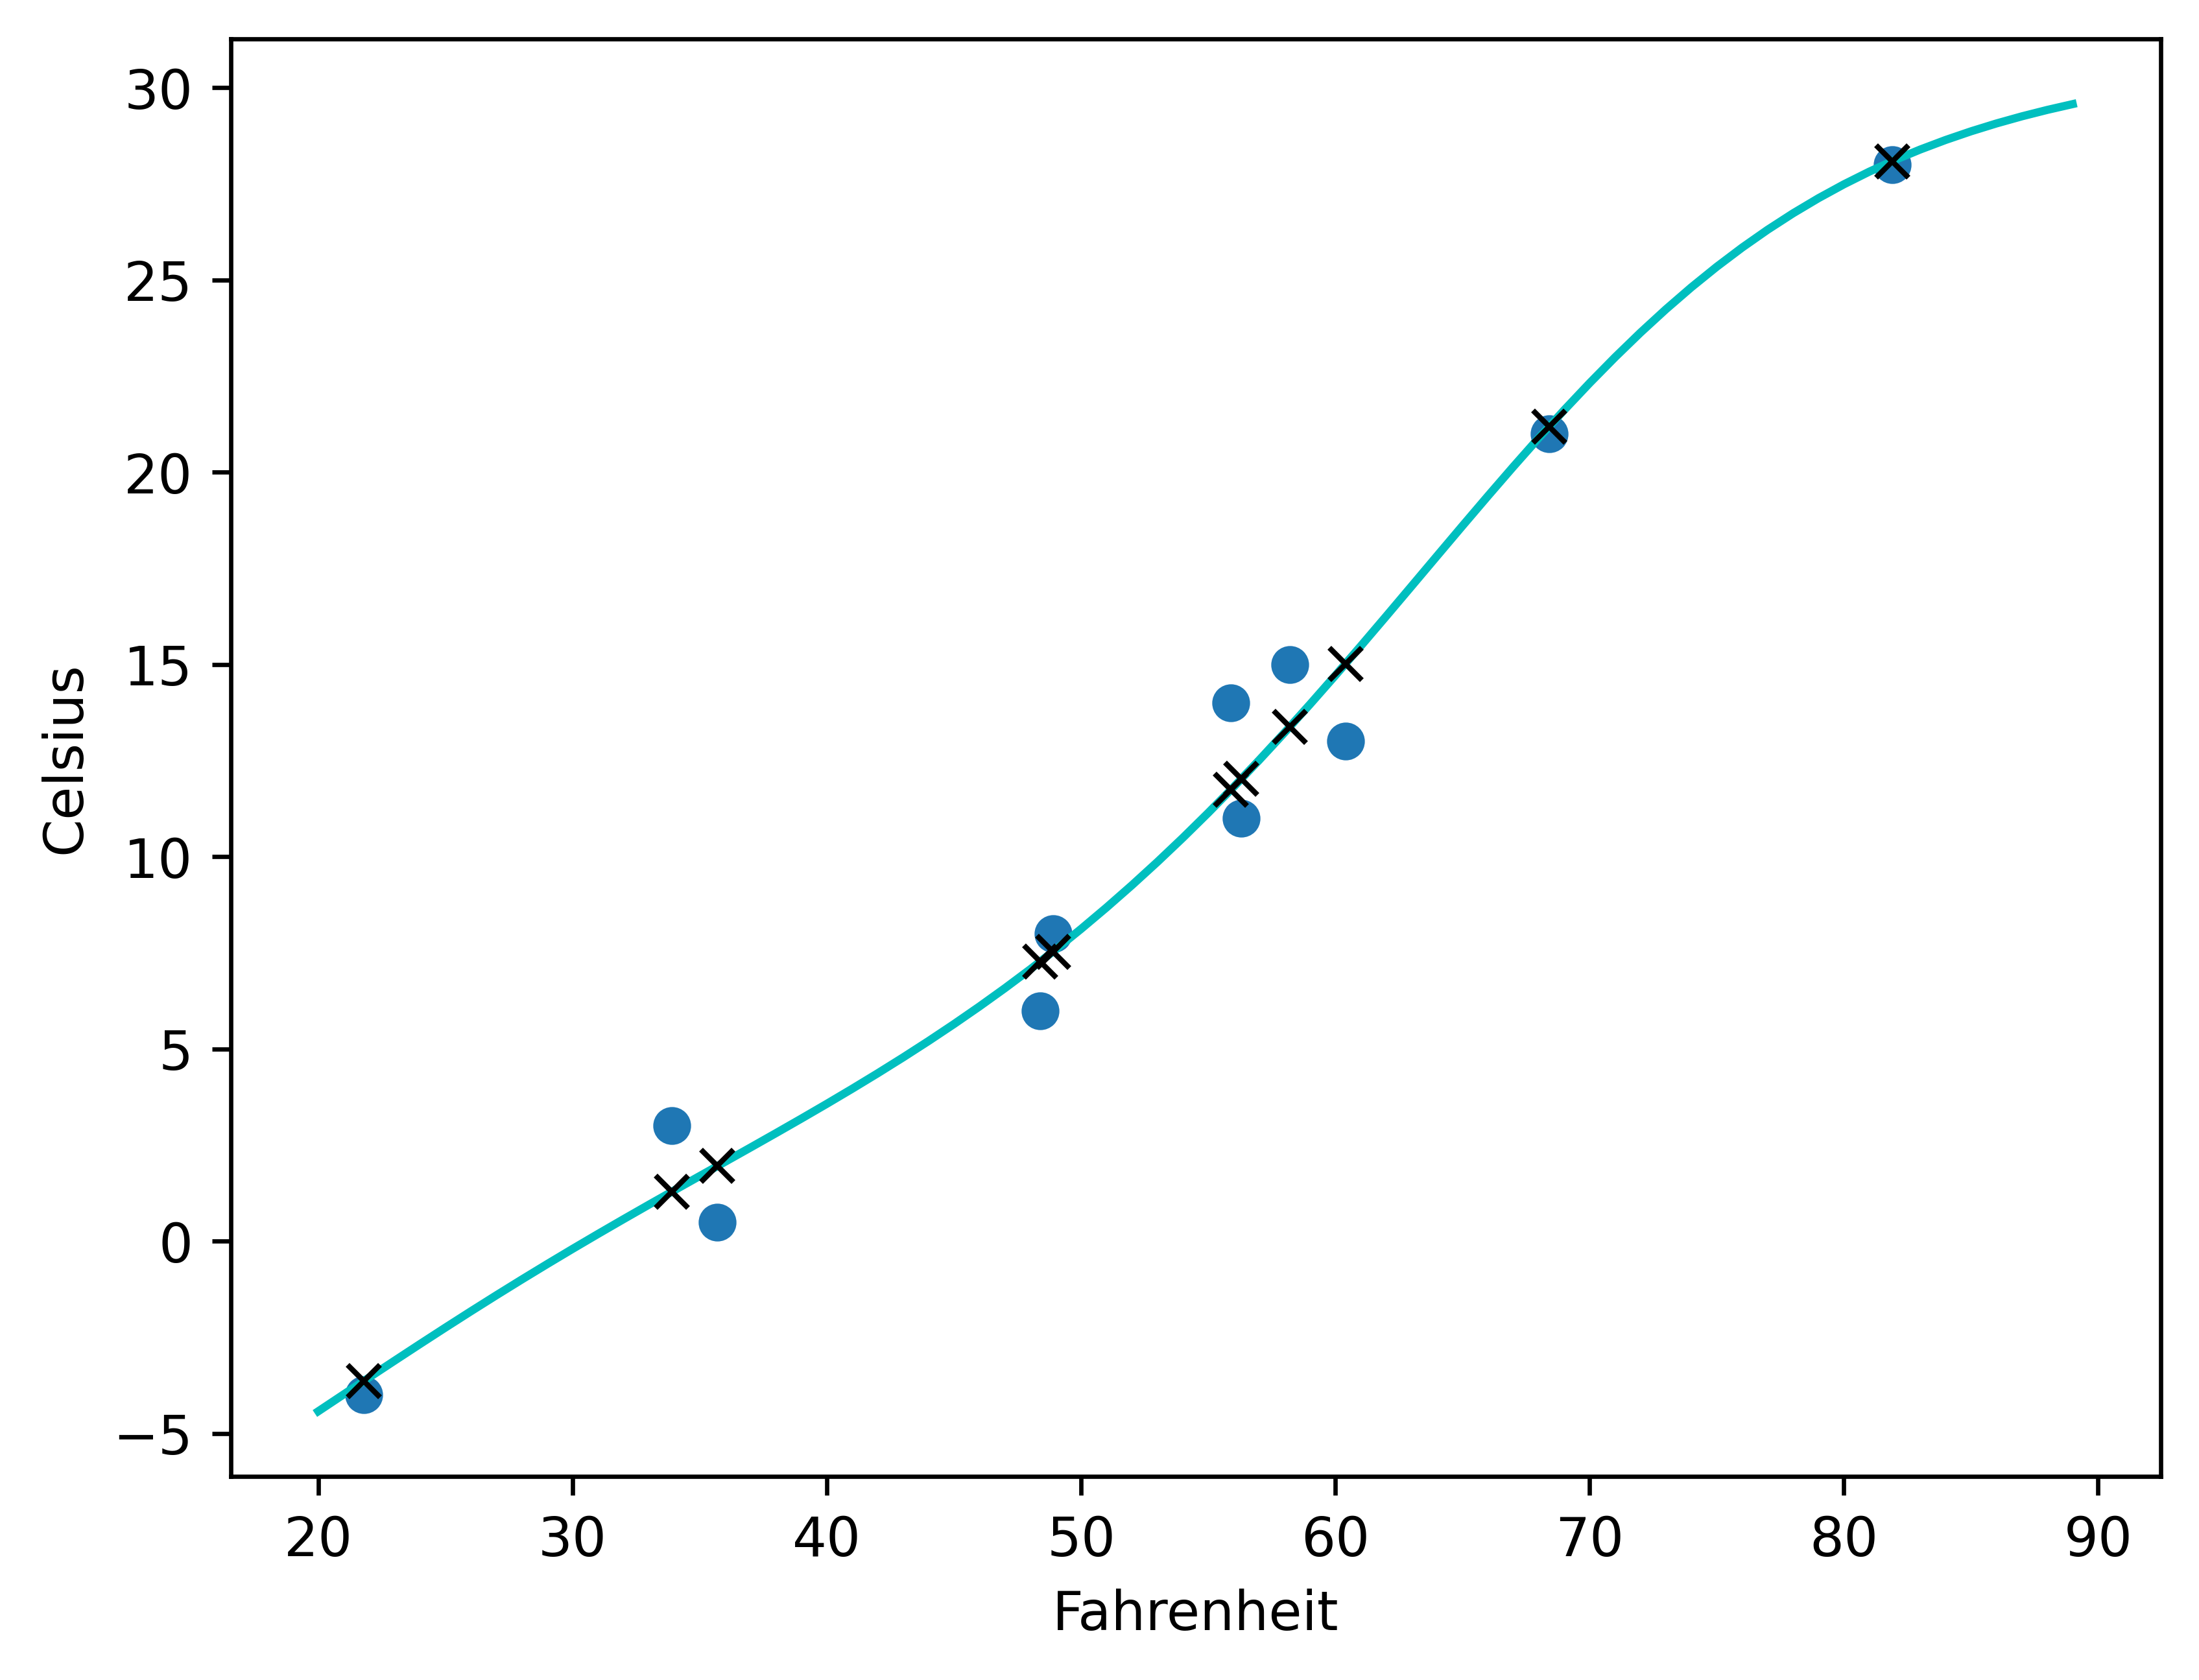

In [21]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi = 600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')
plt.show()

결과를 보면 신경망이 노이즈까지 포함해서 측정값을 과도하게 따라가는 과적합 성향을 보임을 알 수 있다. 작디 작은 신경망임에도 측정값이 얼마 되지 않기 때문에 상대적으로 적합에 필요한 양보다 많은 파라미터를 가지고 있는 셈이다. 그래도 결과적으로는 나쁘지 않다.

## 6.4 결론

미분 가능한 모델을 만들고 경사 하강을 통해 처음에는 자동미분으로, 두 번째는 `nn`으로 훈련도 진행했다. 이를 통해 신경망 내부가 파이토치를 통해 어떻게 동작하는지 이해하였다.

## 6.5 연습문제

1. 간단한 신경망 모델에서 여러은닉층 뉴런과 학습률로 실험해보라.

    - a. 어떤 값을 바꿀 때 모델의 출력이 더욱 선형이 되었나?
    - b. 확실하게 과적합하는 모델을 만들 수 있는가?

In [22]:
# 훈련 및 파라미터 추적하기

from collections import OrderedDict
seq_model_2 = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, 8)),
    ('hidden_activation', nn.ReLU()),
    ('hidden_linear2', nn.Linear(8, 12)),
    ('hidden_activation2', nn.ReLU()),
    ('output_linear', nn.Linear(12, 1))
]))


optimizer_2 = optim.SGD(seq_model_2.parameters(), lr = 1e-4)

training_loop(
    n_epochs=25_000,
    optimizer = optimizer_2,
    model = seq_model_2,
    loss_fn = nn.MSELoss(),
    train_t_u = t_un_train,
    val_t_u = t_un_val,
    train_t_c = t_c_train,
    val_t_c = t_c_val)

print('output', seq_model_2(t_un_val))
print('answer', t_c_val)
print('hidden', seq_model_2.hidden_linear.weight.grad)

Epoch 1, Training loss 187.5905, Validation loss 134.2953
Epoch 2, Training loss 186.9485, Validation loss 133.6991
Epoch 3, Training loss 186.3020, Validation loss 133.0988
Epoch 500, Training loss 36.6146, Validation loss 7.2042
Epoch 1000, Training loss 33.6097, Validation loss 6.8546
Epoch 1500, Training loss 30.2752, Validation loss 6.4301
Epoch 2000, Training loss 26.1278, Validation loss 5.8380
Epoch 2500, Training loss 20.4824, Validation loss 4.9315
Epoch 3000, Training loss 13.1875, Validation loss 3.6318
Epoch 3500, Training loss 6.8787, Validation loss 2.3434
Epoch 4000, Training loss 4.4381, Validation loss 1.5501
Epoch 4500, Training loss 3.3908, Validation loss 1.1500
Epoch 5000, Training loss 3.0608, Validation loss 0.9869
Epoch 5500, Training loss 2.9678, Validation loss 0.9247
Epoch 6000, Training loss 2.9375, Validation loss 0.9008
Epoch 6500, Training loss 2.9241, Validation loss 0.8916
Epoch 7000, Training loss 2.9168, Validation loss 0.8883
Epoch 7500, Training lo

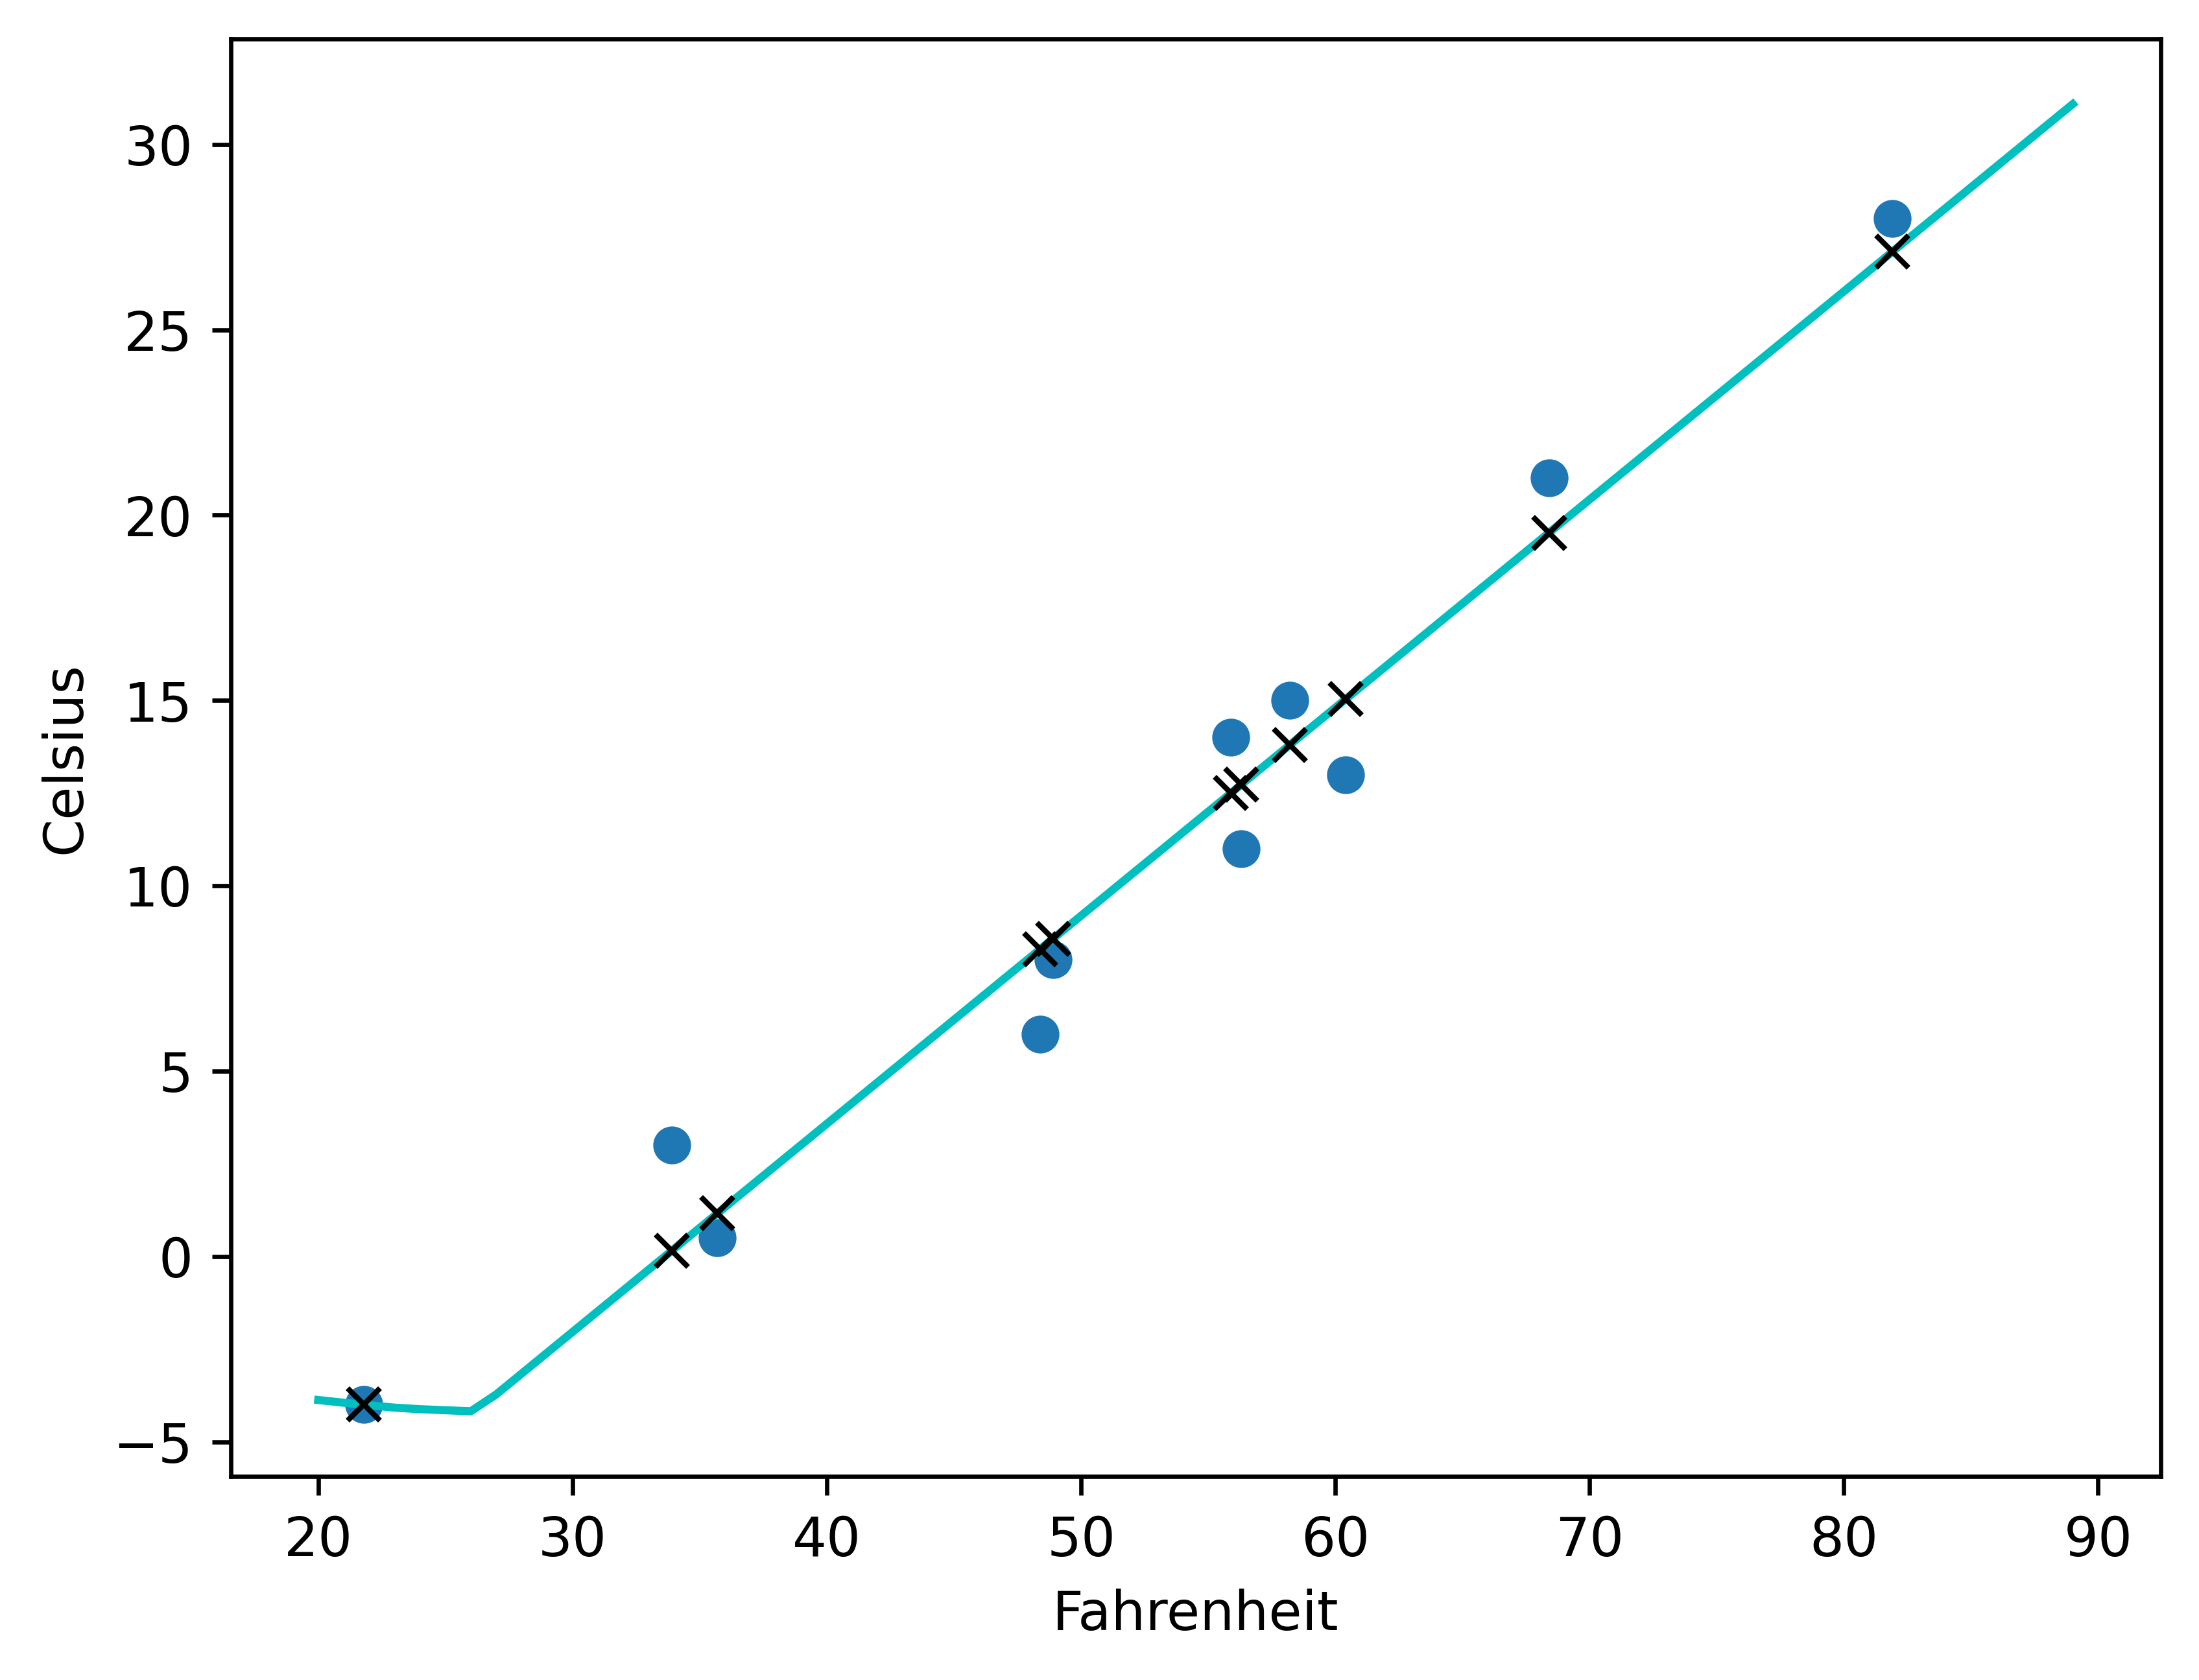

In [23]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi = 600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model_2(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model_2(0.1 * t_u).detach().numpy(), 'kx')
plt.show()

주로 은닉 계층 수가 늘어날 때 모델의 출력이 더욱 선형이 되었고, 학습률과 에포크수는 그렇게 큰 영향을 주지 못했다.

확실하게 과적합하려면 데이터가 좀 더 필요할 것 같다.

2. 물리학에서 세 번째로 어려운 문제를 꼽자면 새로운 발견 성과를 자축할 때 쓸 적당한 와인을 찾는 것이다. 4장의 와인 데이터를 읽어서 적당한 수의 입력 파라미터를 가지는 모델을 만들어라.

    - a. 앞에서 다룬 온도 데이터와 비교할 때 훈련 시간이 얼마나 더 오래 걸리는가?
    - b. 어떤 요소가 훈련 시간에 영향을 주는지 설명할 수 있는가?
    - c. 데이터셋으로 훈련시키는 동안 손실이 줄어들었나?
    - d. 데이터셋을 어떻게 그래프로 표현할 것인가?

In [24]:
# 32비트 부동소수점, 각 행 구별 구분자 지정, 각 열 이름을 나타내는 첫 행 생략하도록 데이터 불러오기
import csv, os, sys
import pandas as pd

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

BASE_DIR = os.getcwd()
sys.path.append(BASE_DIR)
DATA_PATH = os.path.join(BASE_DIR, "data")
wine_path = os.path.join(DATA_PATH, "p1ch4", "tabular-wine", "winequality-white.csv")
wineq_numpy = np.loadtxt(wine_path, dtype=np.float32, delimiter=";", skiprows=1)

wine_df = pd.read_csv(wine_path, delimiter=";")
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [61]:
# 데이터셋 준비
X = wine_df.iloc[:, :-1].to_numpy()
y = wine_df.iloc[:, -1].to_numpy()

X = torch.tensor(X)
y = torch.tensor(y)

print(X.shape)
N = X.shape[0]
N_val = int(0.2 * N)

shuffled_indices = torch.randperm(N)

train_indices = shuffled_indices[:-N_val]
val_indices = shuffled_indices[-N_val:]

X_train, y_train = X[train_indices], y[train_indices].unsqueeze(-1)
X_val, y_val = X[val_indices], y[val_indices].unsqueeze(-1)

# 전처리 : z-score화
X_train_mean = torch.mean(X_train, dim = 0)
X_train_std = torch.std(X_train, dim = 0)

X_train_processed = (X_train - X_train_mean) / X_train_std
X_val_processed = (X_val - X_train_mean) / X_train_std

# to tensor
device = "cuda"
X_train_processed = X_train_processed.to(dtype = torch.float32, device=device)
X_val_processed = X_val_processed.to(dtype = torch.float32, device=device)
y_train = y_train.to(dtype = torch.float32, device=device)
y_val = y_val.to(dtype = torch.float32, device=device)

from torch.utils.data import TensorDataset, DataLoader

batch_size = 64 # Example batch size
train_dataset = TensorDataset(X_train_processed, y_train)
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(X_val_processed, y_val)
val_data_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

torch.Size([4898, 11])


In [34]:
y_val.shape

torch.Size([979, 1])

In [78]:
# 수정된 훈련 루프
def train_loop(n_epochs, optimizer:optim.Optimizer, model:nn.Module, loss_fn:nn.Module,
                  train_data_loader:DataLoader, val_data_loader:DataLoader):
    for epoch in range(1, n_epochs + 1):
        # -------------------
        # Train
        # -------------------
        model.train()
        train_loss_sum = 0.0
        train_count = 0
        
        for (X_train_b, y_train_b) in train_data_loader:
            alpha = 0.05
            X_train_b = X_train_b + alpha * torch.randn_like(X_train_b)
            train_pred = model(X_train_b) # model이 파라미터를 내부적으로 들고있으므로 명시적으로 params 전달필요 X
            loss_train = loss_fn(train_pred, y_train_b)
            
            optimizer.zero_grad() # loss_train.backward()전에 무조건 grad 초기화 한번은 해줘야한다(안그럼 누적되서 망함)
            loss_train.backward()
            optimizer.step()

            bs = X_train_b.size(0)
            train_loss_sum += loss_train * bs
            train_count += bs

        train_loss_epoch = train_loss_sum / train_count

        # -------------------
        # Validation
        # -------------------
        model.eval()
        val_loss_sum = 0.0
        val_count = 0
        
        with torch.no_grad():
            for X_val_b, y_val_b in val_data_loader:
                val_pred = model(X_val_b)
                loss_val = loss_fn(val_pred, y_val_b)

                bs = X_val_b.size(0)
                val_loss_sum += loss_val * bs
                val_count += bs
        
        val_loss_epoch = val_loss_sum / val_count
                
        if epoch <= 10 or epoch % 10 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss_epoch:.4f},"
                f" Validation loss {val_loss_epoch:.4f}")
            


In [79]:
# 훈련 및 파라미터 추적하기

from collections import OrderedDict
input_dim = 11
wine_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(input_dim, 64)),
    ('hidden_activation', nn.ReLU()),
    ('hidden_dropout', nn.Dropout(p=0.4)),
    ('hidden_linear2', nn.Linear(64, 64)),
    ('hidden_activation2', nn.ReLU()),
    ('hidden_dropout2', nn.Dropout(p=0.4)),
    ('hidden_linear3', nn.Linear(64, 32)),
    ('hidden_activation3', nn.ReLU()),
    ('hidden_dropout3', nn.Dropout(p=0.4)),
    ('hidden_linear4', nn.Linear(32, 16)),
    ('hidden_activation4', nn.ReLU()),
    ('hidden_dropout4', nn.Dropout(p=0.4)),
    ('output_linear', nn.Linear(16, 1))
]))

wine_model.to(device)
optimizer = optim.Adam(wine_model.parameters(), lr=1e-3, weight_decay=1e-4)
batch_size = 64

train_loop(
    n_epochs=500,
    optimizer = optimizer,
    model = wine_model,
    loss_fn = nn.MSELoss(),
    train_data_loader = train_data_loader,
    val_data_loader = val_data_loader)

# print('output', wine_model(t_un_val))
print('train finished')

Epoch 1, Training loss 25.4883, Validation loss 2.9517
Epoch 2, Training loss 8.0593, Validation loss 3.2433
Epoch 3, Training loss 6.4477, Validation loss 1.7599
Epoch 4, Training loss 5.8355, Validation loss 2.1736
Epoch 5, Training loss 5.1254, Validation loss 1.7776
Epoch 6, Training loss 5.1290, Validation loss 1.3504
Epoch 7, Training loss 4.7252, Validation loss 1.5530
Epoch 8, Training loss 4.7333, Validation loss 1.3512
Epoch 9, Training loss 4.5980, Validation loss 1.2818
Epoch 10, Training loss 4.3885, Validation loss 1.4316
Epoch 20, Training loss 3.4226, Validation loss 1.3567
Epoch 30, Training loss 2.9765, Validation loss 0.9034
Epoch 40, Training loss 2.2905, Validation loss 0.7770
Epoch 50, Training loss 1.9848, Validation loss 0.8876
Epoch 60, Training loss 1.6652, Validation loss 0.7524
Epoch 70, Training loss 1.4494, Validation loss 0.6503
Epoch 80, Training loss 1.2479, Validation loss 0.5558
Epoch 90, Training loss 1.0886, Validation loss 0.6058
Epoch 100, Trainin

In [80]:
wine_model.eval()
y_pred = wine_model(X_val_processed)

In [58]:
# y_pred = y_pred.to(device='cpu').detach().numpy().astype(np.int64)
# y_val = y_val.to(device='cpu').detach().numpy().astype(np.int64)


In [59]:
# cond = (y_pred == y_val)
# pred_counter = np.where(cond, 1, 0)
# n_total = len(y_pred)
# n_correct = np.sum(pred_counter)

# print(f"acc : {n_correct/n_total:.4f}")

In [72]:
wine_model.eval()
with torch.no_grad():
    y_pred = wine_model(X_val_processed)

y_pred_np = y_pred.cpu().numpy().squeeze()
y_val_np = y_val.cpu().numpy().squeeze()

mae = np.mean(np.abs(y_pred_np - y_val_np))
mse = np.mean((y_pred_np - y_val_np) ** 2)
rmse = np.sqrt(mse)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE:  0.5815
MSE:  0.5615
RMSE: 0.7493


In [81]:
# after
wine_model.eval()
with torch.no_grad():
    y_pred = wine_model(X_val_processed)

y_pred_np = y_pred.cpu().numpy().squeeze()
y_val_np = y_val.cpu().numpy().squeeze()

mae = np.mean(np.abs(y_pred_np - y_val_np))
mse = np.mean((y_pred_np - y_val_np) ** 2)
rmse = np.sqrt(mse)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE:  0.5310
MSE:  0.4706
RMSE: 0.6860


In [73]:
wine_model.eval()
with torch.no_grad():
    y_pred = wine_model(X_val_processed)

y_pred_np = y_pred.cpu().numpy().squeeze()
y_val_np = y_val.cpu().numpy().squeeze().astype(np.int64)

# 반올림 후, 라벨 범위로 자르기
y_pred_cls = np.rint(y_pred_np).astype(np.int64)   # round to nearest
y_pred_cls = np.clip(y_pred_cls, y_val_np.min(), y_val_np.max())

acc = np.mean(y_pred_cls == y_val_np)
print(f"acc (rounded): {acc:.4f}")

acc (rounded): 0.5312


In [82]:
# after
wine_model.eval()
with torch.no_grad():
    y_pred = wine_model(X_val_processed)

y_pred_np = y_pred.cpu().numpy().squeeze()
y_val_np = y_val.cpu().numpy().squeeze().astype(np.int64)

# 반올림 후, 라벨 범위로 자르기
y_pred_cls = np.rint(y_pred_np).astype(np.int64)   # round to nearest
y_pred_cls = np.clip(y_pred_cls, y_val_np.min(), y_val_np.max())

acc = np.mean(y_pred_cls == y_val_np)
print(f"acc (rounded): {acc:.4f}")

acc (rounded): 0.5904


acc (rounded): 0.5904
±1 acc:        0.9551


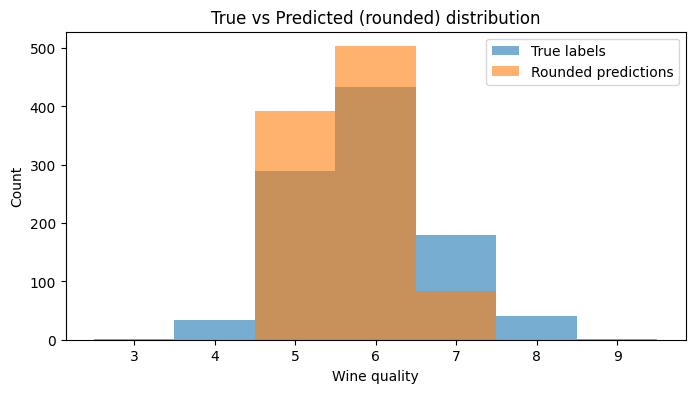

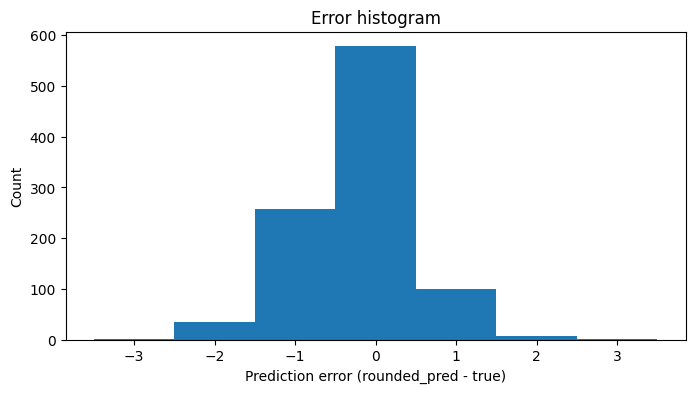

In [83]:
# 반올림 + 클리핑 (라벨 범위에 맞추기)
y_min, y_max = int(y_val_np.min()), int(y_val_np.max())
y_pred_round = np.rint(y_pred_np).astype(np.int64)
y_pred_round = np.clip(y_pred_round, y_min, y_max)

y_val_int = y_val_np.astype(np.int64)

# 정확도 / ±1 정확도
acc = np.mean(y_pred_round == y_val_int)
acc_pm1 = np.mean(np.abs(y_pred_round - y_val_int) <= 1)

print(f"acc (rounded): {acc:.4f}")
print(f"±1 acc:        {acc_pm1:.4f}")

# 1) 실제 vs 예측 라벨 분포 히스토그램
bins = np.arange(y_min - 0.5, y_max + 1.5, 1)

plt.figure(figsize=(8, 4))
plt.hist(y_val_int, bins=bins, alpha=0.6, label='True labels')
plt.hist(y_pred_round, bins=bins, alpha=0.6, label='Rounded predictions')
plt.xticks(np.arange(y_min, y_max + 1))
plt.xlabel("Wine quality")
plt.ylabel("Count")
plt.title("True vs Predicted (rounded) distribution")
plt.legend()
plt.show()

# 2) 오차 히스토그램 (반올림 기준)
err_round = y_pred_round - y_val_int

plt.figure(figsize=(8, 4))
err_bins = np.arange(err_round.min() - 0.5, err_round.max() + 1.5, 1)
plt.hist(err_round, bins=err_bins)
plt.xticks(np.arange(err_round.min(), err_round.max() + 1))
plt.xlabel("Prediction error (rounded_pred - true)")
plt.ylabel("Count")
plt.title("Error histogram")
plt.show()

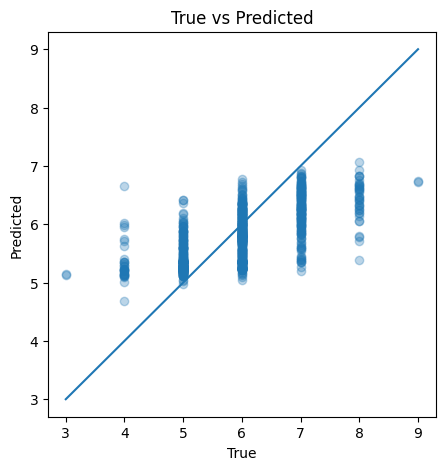

In [84]:
plt.figure(figsize=(5, 5))
plt.scatter(y_val_np, y_pred_np, alpha=0.3)
mn = min(y_val_np.min(), y_pred_np.min())
mx = max(y_val_np.max(), y_pred_np.max())
plt.plot([mn, mx], [mn, mx])  # y=x 기준선
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.show()

## 6.6 핵심 요약

- 신경망은 특정 문제를 풀기 위해 적합한 형태로 스스로를 최적화할 수 있다.
- 신경망은 모델의 어떤 파라미터에 대해서라도 손실값의 미분에 대해 쉽게 접근할 수 있게 하여 파라미터가 매우 효율적으로 진화하도록 만들어준다. 감사하게도 파이토치의 자동화된 미분 엔진을 통해 이러한 미분 과정을 쉽게 사용할 수 있다.
- 선형 변환을 둘러싼 활성 함수 덕분에 신경망은 상당히 비선형적인 함수에 대해서도 근사할 수 있으며 동시에 최적화하기에 충분한 수준으로 단순한 형태를 유지할 수 있다.
- `nn`모듈과 표준 텐서 라이브러리는 신경망을 만들기 위한 모든 빌딩 블럭을 제공한다.
- 과적합을 감지하기 위해 훈련셋을 검증셋과 분리해서 유지하는 것은 필수적이다. 과적합을 방지하는 방법은 다양하다. 더 많은 데이터를 구하거나, 데이터가 더욱 다양한 값을 가지게 한다든가, 더 단순한 모델을 사용하는 방법 등을 먼저 시도해볼 만하다.
- 데이터과학을 하는 사람이라면 항상 데이터를 차트에 그려봐야 한다.